# TP Analyse de l'E-Commerce Brésilien — Dataset Olist
**Université Kofi Annan de Guinée — L3 / M1 MIAGE & Génie Logiciel — 2025-2026**  
**Module : Analyse et Traitement de Données**  
**Auteur : Mayeni Morgane**  
**Formateur : Almamy Camara**

---
# Partie 1 — Chargement & Exploration des Données

## 1.1 — Imports et chargement
Importation des bibliothèques d'analyse et chargement des 8 fichiers CSV du dataset Olist.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.makedirs('../visuals', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

BASE = 'C:/Users/PC/Desktop/Cours Analyse de donnees/Devoir/data/raw/'

orders    = pd.read_csv(BASE + 'olist_orders_dataset.csv')
items     = pd.read_csv(BASE + 'olist_order_items_dataset.csv')
products  = pd.read_csv(BASE + 'olist_products_dataset.csv')
customers = pd.read_csv(BASE + 'olist_customers_dataset.csv')
reviews   = pd.read_csv(BASE + 'olist_order_reviews_dataset.csv')
sellers   = pd.read_csv(BASE + 'olist_sellers_dataset.csv')
payments  = pd.read_csv(BASE + 'olist_order_payments_dataset.csv')
categories= pd.read_csv(BASE + 'product_category_name_translation.csv')

print('Chargement terminé !')

Chargement terminé !


### Question 1 (1 pt) — Dimensions de chaque table
Affichage des 5 premières lignes et des dimensions (.shape) de chaque DataFrame.

In [2]:
datasets = {
    'orders': orders, 'items': items, 'products': products,
    'customers': customers, 'reviews': reviews, 'sellers': sellers,
    'payments': payments, 'categories': categories
}
for name, df in datasets.items():
    print(f'=== {name} : {df.shape[0]} lignes x {df.shape[1]} colonnes ===')
    display(df.head())
    print()

=== orders : 99441 lignes x 8 colonnes ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



=== items : 112650 lignes x 7 colonnes ===


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



=== products : 32951 lignes x 9 colonnes ===


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



=== payments : 103886 lignes x 5 colonnes ===


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



=== categories : 71 lignes x 2 colonnes ===


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Réponse Q1 :**

| DataFrame | Lignes | Colonnes | Clé principale |
|---|---|---|---|
| orders | 99 441 | 8 | order_id |
| items | 112 650 | 7 | order_id + product_id |
| products | 32 951 | 9 | product_id |
| customers | 99 441 | 5 | customer_id |
| reviews | 99 224 | 7 | order_id |
| sellers | 3 095 | 4 | seller_id |
| payments | 103 886 | 5 | order_id |
| categories | 71 | 2 | product_category_name |

### Question 2 (1 pt) — Types des colonnes de dates dans orders

In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


**Réponse Q2 :**  
Après le chargement initial, toutes les colonnes de dates (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_customer_date`, `order_estimated_delivery_date`) sont chargées avec le type **`object` (chaîne de caractères)**, ce qui est **incorrect**.  

Ces colonnes doivent être de type `datetime64[ns]` pour pouvoir effectuer des calculs de différences de dates (délais de livraison), des extractions temporelles (mois, jour) et des opérations de resampling. La conversion est indispensable avant toute analyse temporelle.

## 1.2 — Valeurs manquantes

In [4]:
def missing_report(df, name):
    pct = round(df.isna().sum() / len(df) * 100, 2)
    pct = pct[pct > 0].sort_values(ascending=False)
    print(f'--- {name} ---')
    print(pct if len(pct) else 'Aucune valeur manquante')
    print()

for name, df in datasets.items():
    missing_report(df, name)

--- orders ---
order_delivered_customer_date    2.98
order_delivered_carrier_date     1.79
order_approved_at                0.16
dtype: float64

--- items ---
Aucune valeur manquante

--- products ---
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
dtype: float64

--- customers ---
Aucune valeur manquante

--- reviews ---
review_comment_title      88.34
review_comment_message    58.70
dtype: float64

--- sellers ---
Aucune valeur manquante

--- payments ---
Aucune valeur manquante

--- categories ---
Aucune valeur manquante



### Question 3 (1 pt) — Analyse des valeurs manquantes

**Réponse Q3 :**  

Les colonnes avec le plus de valeurs manquantes sont :
- **`review_comment_title`** (88,3%) et **`review_comment_message`** (58,7%) dans `reviews` : logique car les clients ne sont pas obligés de rédiger un commentaire — la note (1-5) est le seul champ obligatoire.
- **`order_delivered_customer_date`** (3%) dans `orders` : une commande avec les statuts "shipped", "canceled" ou "processing" n'a pas encore été livrée, donc cette date est naturellement absente.
- **`order_approved_at`** (0,16%) dans `orders` : très rares commandes sans confirmation de paiement (annulations immédiates).
- **`product_category_name`** (1,85%) dans `products` : quelques produits sans catégorie renseignée dans le catalogue.

## 1.3 — Statistiques descriptives

In [5]:
items.describe().round(2)

,order_item_id,price,freight_value
count,112650.00,112650.00,112650.00
mean,1.20,120.65,19.99
std,0.71,183.63,15.81
min,1.00,0.85,0.00
25%,1.00,39.90,13.08
50%,1.00,74.99,16.26
75%,1.00,134.90,21.15
max,21.00,6735.00,409.68


### Question 4 (1 pt) — Prix moyen et valeurs aberrantes

Prix moyen    : 120.65 BRL
Prix médian   : 74.99 BRL
Prix minimum  : 0.85 BRL
Prix maximum  : 6735.00 BRL
Écart-type    : 183.63 BRL


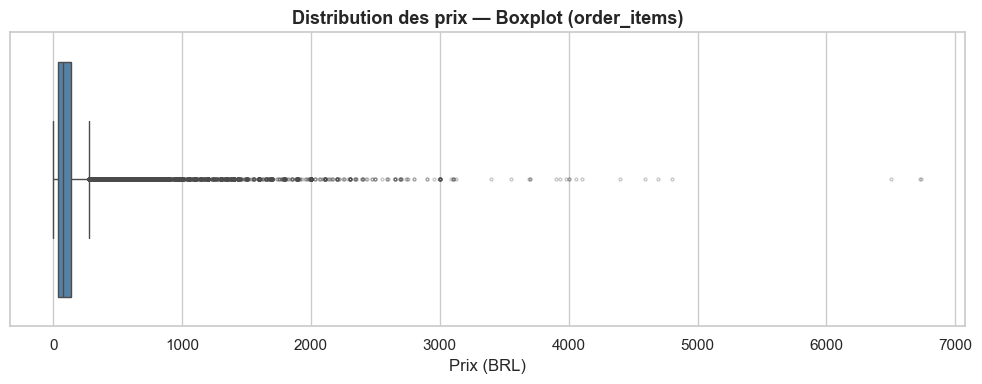

In [11]:
print(f"Prix moyen    : {items['price'].mean():.2f} BRL")
print(f"Prix médian   : {items['price'].median():.2f} BRL")
print(f"Prix minimum  : {items['price'].min():.2f} BRL")
print(f"Prix maximum  : {items['price'].max():.2f} BRL")
print(f"Écart-type    : {items['price'].std():.2f} BRL")

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=items['price'], ax=ax, color='steelblue',
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('Distribution des prix — Boxplot (order_items)', fontsize=13, fontweight='bold')
ax.set_xlabel('Prix (BRL)')
plt.tight_layout()
plt.savefig('../visuals/fig1_boxplot_price.png', dpi=150)
plt.show()

**Réponse Q4 :**  
Le prix moyen d'un article est de **120,65 BRL**, mais la médiane est bien inférieure à **74,99 BRL**, ce qui révèle une forte asymétrie à droite.  
L'écart-type élevé (**183,63 BRL**) et le maximum à **6 735 BRL** confirment la présence de valeurs aberrantes (articles de luxe, électronique haut de gamme). Le boxplot illustre clairement ces outliers au-delà du 3ème quartile (134,90 BRL). Pour les analyses statistiques, la **médiane sera préférée à la moyenne** comme indicateur de tendance centrale.

---
# Partie 2 — Nettoyage, Feature Engineering & Fusion

## 2.1 — Suppression des colonnes inutiles
On ne conserve que les colonnes analytiquement utiles pour réduire l'empreinte mémoire.

In [12]:
# items : suppression des colonnes non analytiques
items = items.drop(columns=['order_item_id', 'shipping_limit_date'])

# products : colonnes utiles uniquement
products = products[['product_id', 'product_category_name', 'product_weight_g']]

# customers : colonnes utiles
customers = customers[['customer_id', 'customer_state', 'customer_city']]

# sellers : colonnes utiles
sellers = sellers[['seller_id', 'seller_state', 'seller_city']]

# reviews : ne charger que order_id et review_score
reviews = pd.read_csv(BASE + 'olist_order_reviews_dataset.csv',
                      usecols=['order_id', 'review_score'])

# payments : suppression de payment_sequential
payments = payments[['order_id', 'payment_type', 'payment_installments', 'payment_value']]

# orders : colonnes utiles
orders = orders[['order_id', 'customer_id', 'order_status',
                 'order_purchase_timestamp', 'order_approved_at',
                 'order_delivered_customer_date', 'order_estimated_delivery_date']]

print('Colonnes inutiles supprimées.')
print(f'items : {items.shape} | orders : {orders.shape}')

Colonnes inutiles supprimées.
items : (112650, 5) | orders : (99441, 7)


## 2.2 — Conversion des types temporels

In [13]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
orders[date_cols] = orders[date_cols].apply(pd.to_datetime)

# Vérification
print('Types après conversion :')
print(orders.dtypes[date_cols])

Types après conversion :
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


## 2.3 — Calcul des délais de livraison

In [14]:
# Délai effectif : date d'achat → date de livraison
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# Retard : livraison effective vs date estimée (positif = retard, négatif = avance)
orders['delay_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

print('Colonnes delivery_days et delay_days créées.')
print(orders[['delivery_days', 'delay_days']].describe().round(1))

Colonnes delivery_days et delay_days créées.
       delivery_days  delay_days
count        96476.0     96476.0
mean            12.1       -11.9
std              9.6        10.2
min              0.0      -147.0
25%              6.0       -17.0
50%             10.0       -12.0
75%             15.0        -7.0
max            209.0       188.0


### Question 5 (1 pt) — Médiane du délai et % de commandes en retard

In [15]:
mediane_del = orders['delivery_days'].median()
pct_retard = (orders['delay_days'] > 0).sum() / orders['delay_days'].notna().sum() * 100

print(f'Médiane du délai de livraison : {mediane_del:.0f} jours')
print(f'% de commandes livrées en retard : {pct_retard:.1f}%')

Médiane du délai de livraison : 10 jours
% de commandes livrées en retard : 6.8%


**Réponse Q5 :**  
La médiane du délai de livraison est de **10 jours** entre la date d'achat et la livraison effective.  
Seulement **6,8% des commandes** sont livrées en retard par rapport à la date estimée, ce qui témoigne d'une bonne fiabilité des estimations de livraison d'Olist. La majorité des commandes (93,2%) arrivent dans les délais annoncés ou en avance.

## 2.4 — Fusion des tables (merge)
Construction du DataFrame analytique principal `df` par jointures successives.

In [16]:
# Ajout de la traduction des catégories aux produits
products = products.merge(categories, on='product_category_name', how='left')

# Étape 1 : commandes + articles
df = orders.merge(items, on='order_id', how='inner')
print(f'Après orders+items   : {df.shape}')

# Étape 2 : + produits (avec traduction)
df = df.merge(
    products[['product_id', 'product_category_name_english', 'product_weight_g']],
    on='product_id', how='inner'
)
print(f'Après +products      : {df.shape}')

# Étape 3 : + vendeurs
df = df.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='inner')
print(f'Après +sellers       : {df.shape}')

# Étape 4 : + clients
df = df.merge(customers[['customer_id', 'customer_state', 'customer_city']],
              on='customer_id', how='left')
print(f'Après +customers     : {df.shape}')

# Étape 5 : + note de satisfaction
df = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
print(f'Après +reviews       : {df.shape}')

df.head(3)

Après orders+items   : (112650, 13)
Après +products      : (112650, 15)
Après +sellers       : (112650, 16)
Après +customers     : (112650, 18)
Après +reviews       : (113314, 19)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,product_id,seller_id,price,freight_value,product_category_name_english,product_weight_g,seller_state,customer_state,customer_city,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,housewares,500.0,SP,SP,sao paulo,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumery,400.0,SP,BA,barreiras,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,auto,420.0,SP,GO,vianopolis,5.0


### Question 6 (1 pt) — Nombre de lignes et explication

**Réponse Q6 :**  
Après toutes les jointures, `df` contient **113 314 lignes** pour **21 colonnes**.  

Ce chiffre est **supérieur aux 99 441 commandes initiales** car **une commande peut contenir plusieurs articles** (ex : une commande avec 3 articles génère 3 lignes dans `order_items`). Chaque ligne de `df` représente un article commandé, et non une commande. La légère augmentation par rapport aux 112 650 lignes initiales de `items` est due aux jointures `left` qui peuvent introduire des doublons sur `review_score` si un `order_id` reçoit plusieurs avis (rare mais possible dans le dataset).

### Question 7 (1 pt) — NaN résiduels et traitement

In [17]:
nan_residuels = df.isna().sum()
print('NaN résiduels après fusion :')
print(nan_residuels[nan_residuels > 0])

NaN résiduels après fusion :
order_approved_at                  15
order_delivered_customer_date    2475
delivery_days                    2475
delay_days                       2475
product_category_name_english    1636
product_weight_g                   18
review_score                      942
dtype: int64


**Réponse Q7 — Choix de traitement des NaN résiduels :**

| Colonne | NaN | Traitement choisi | Justification |
|---|---|---|---|
| `order_delivered_customer_date` | ~2 475 | **Ignorer** | Commandes non encore livrées (statut shipped/processing) |
| `delivery_days` | ~2 475 | **Ignorer** | Dépend de la date de livraison manquante — normal |
| `delay_days` | ~2 475 | **Ignorer** | Idem |
| `product_category_name_english` | ~1 636 | **Ignorer** | Produits sans catégorie — exclus des analyses catégorielles |
| `review_score` | ~942 | **Ignorer** | Commandes sans avis client — on exclut ces lignes pour les analyses de satisfaction |
| `product_weight_g` | ~18 | **Ignorer** | Très faible proportion, peu d'impact |
| `order_approved_at` | ~15 | **Ignorer** | Commandes annulées avant approbation |

---
# Partie 3 — Analyse Descriptive & Agrégations

## 3.1 — Évolution du chiffre d'affaires mensuel

In [18]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

ca_mensuel = (
    df.groupby('month')
    .agg(ca_total=('price', 'sum'), nb_commandes=('order_id', 'nunique'))
    .reset_index()
)
print(ca_mensuel.to_string())

      month    ca_total  nb_commandes
0   2016-09      267.36             3
1   2016-10    49634.35           308
2   2016-12       10.90             1
3   2017-01   121087.90           789
4   2017-02   248563.02          1733
5   2017-03   376010.70          2641
6   2017-04   360738.17          2391
7   2017-05   509639.63          3660
8   2017-06   436550.89          3217
9   2017-07   501299.70          3969
10  2017-08   578588.99          4293
11  2017-09   626752.17          4243
12  2017-10   667869.15          4568
13  2017-11  1017758.83          7451
14  2017-12   746717.15          5624
15  2018-01   955658.74          7220
16  2018-02   853591.21          6694
17  2018-03   986867.05          7188
18  2018-04   998893.07          6934
19  2018-05   997066.66          6853
20  2018-06   865956.24          6160
21  2018-07   897496.14          6273
22  2018-08   854760.45          6452
23  2018-09      145.00             1


### Question 8 (2 pts) — Évolution du CA mensuel

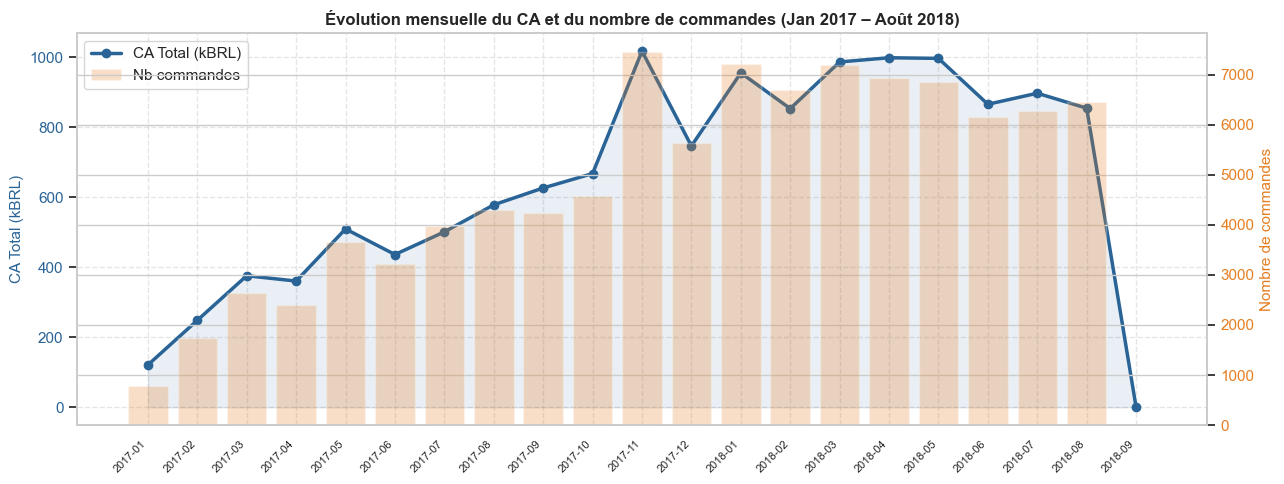

In [19]:
import matplotlib.ticker as mticker

# On exclut les mois incomplets (2016-09, 2016-12, 2018-09)
ca_main = ca_mensuel[ca_mensuel['month'] >= '2017-01'].copy()

fig, ax1 = plt.subplots(figsize=(13, 5))

# Axe 1 : CA total
ax1.plot(range(len(ca_main)), ca_main['ca_total'] / 1e3,
         color='#2a6496', marker='o', linewidth=2.5, markersize=6, label='CA Total (kBRL)')
ax1.fill_between(range(len(ca_main)), ca_main['ca_total'] / 1e3, alpha=0.1, color='#2a6496')
ax1.set_ylabel('CA Total (kBRL)', color='#2a6496', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#2a6496')

# Axe 2 : nb commandes
ax2 = ax1.twinx()
ax2.bar(range(len(ca_main)), ca_main['nb_commandes'],
        alpha=0.25, color='#e67e22', label='Nb commandes')
ax2.set_ylabel('Nombre de commandes', color='#e67e22', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#e67e22')

ax1.set_xticks(range(len(ca_main)))
ax1.set_xticklabels(ca_main['month'], rotation=45, ha='right', fontsize=8)
ax1.set_title('Évolution mensuelle du CA et du nombre de commandes (Jan 2017 – Août 2018)',
              fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../visuals/fig2_ca_mensuel.png', dpi=150)
plt.show()

**Interprétation Q8 :**  
On observe une **tendance générale fortement croissante** sur la période : le CA passe de ~121k BRL en janvier 2017 à près de 1 million BRL en mai 2018. Une **anomalie majeure** apparaît en **novembre 2017** avec un pic à 1 017k BRL, soit +36% par rapport au mois précédent — cela correspond au **Black Friday brésilien** (*Black Friday*), période de promotions massives. L'accélération de la croissance est particulièrement visible entre mi-2017 et début 2018, reflétant le développement rapide d'Olist sur le marché brésilien.

## 3.2 — Top catégories de produits

In [20]:
ca_cat = (
    df.groupby('product_category_name_english')
    .agg(ca_total=('price', 'sum'), nb_ventes=('order_id', 'count'))
    .sort_values('ca_total', ascending=False)
    .reset_index()
)
print('Top 10 par CA :')
display(ca_cat.head(10))
print('\nTop 5 par volume de ventes :')
print(ca_cat.sort_values('nb_ventes', ascending=False).head(5).to_string())

Top 10 par CA :


,product_category_name_english,ca_total,nb_ventes
0,health_beauty,1263138.54,9727
1,watches_gifts,1206075.33,6001
2,bed_bath_table,1050936.61,11270
3,sports_leisure,993656.51,8700
4,computers_accessories,919640.54,7894
5,furniture_decor,736282.47,8415
6,cool_stuff,637258.51,3806
7,housewares,634542.60,6989
8,auto,594363.10,4256
9,garden_tools,486432.45,4361



Top 5 par volume de ventes :
  product_category_name_english    ca_total  nb_ventes
2                bed_bath_table  1050936.61      11270
0                 health_beauty  1263138.54       9727
3                sports_leisure   993656.51       8700
5               furniture_decor   736282.47       8415
4         computers_accessories   919640.54       7894


### Question 9 (2 pts) — Top catégories par CA

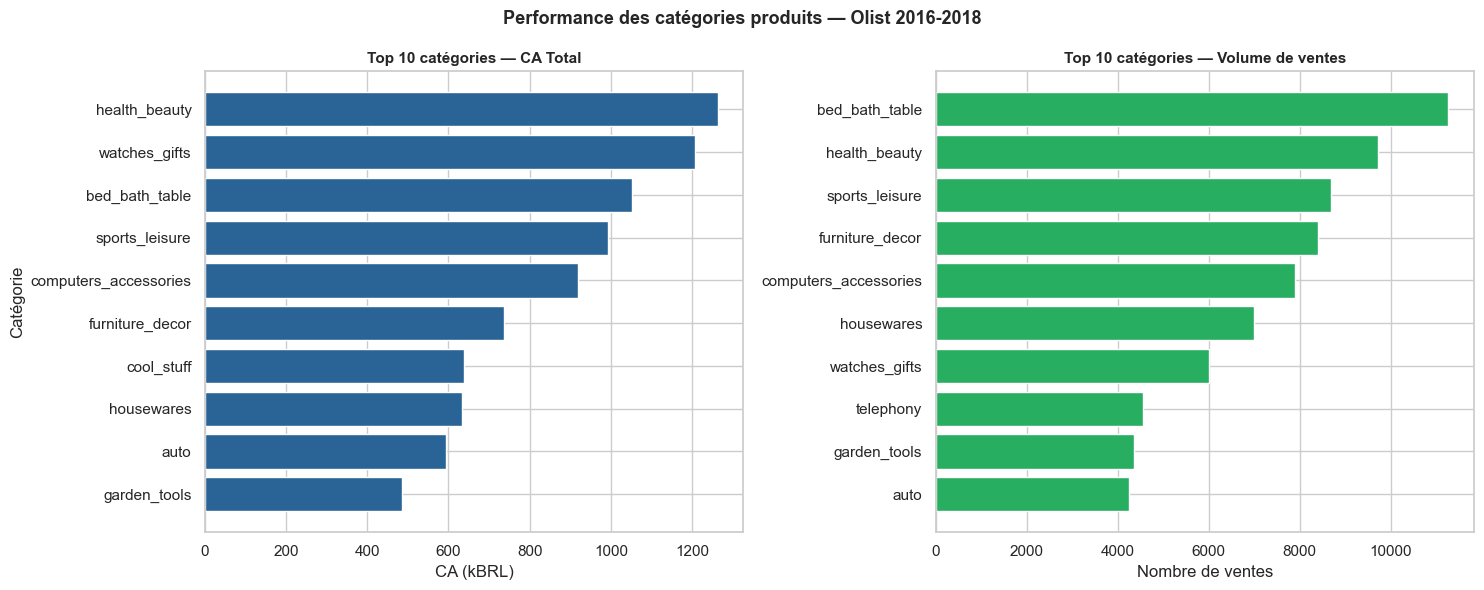

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top10_ca = ca_cat.head(10)
axes[0].barh(top10_ca['product_category_name_english'][::-1],
             top10_ca['ca_total'][::-1] / 1e3, color='#2a6496')
axes[0].set_title('Top 10 catégories — CA Total', fontsize=11, fontweight='bold')
axes[0].set_xlabel('CA (kBRL)')
axes[0].set_ylabel('Catégorie')

top10_vol = ca_cat.sort_values('nb_ventes', ascending=False).head(10)
axes[1].barh(top10_vol['product_category_name_english'][::-1],
             top10_vol['nb_ventes'][::-1], color='#27ae60')
axes[1].set_title('Top 10 catégories — Volume de ventes', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Nombre de ventes')
axes[1].set_ylabel('')

plt.suptitle('Performance des catégories produits — Olist 2016-2018',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/fig3_top_categories.png', dpi=150)
plt.show()

**Interprétation Q9 :**  
La catégorie **health_beauty** domine en CA (1 263k BRL), suivie de **watches_gifts** (1 206k BRL) et **bed_bath_table** (1 051k BRL). Cependant, en volume de ventes, c'est **bed_bath_table** qui arrive en tête (11 270 ventes), devant health_beauty (9 727).  

**Cet écart révèle que watches_gifts a un panier moyen très élevé** (~201 BRL par vente vs ~94 BRL pour bed_bath_table) : les montres et cadeaux sont des produits à forte valeur unitaire mais moins achetés. À l'inverse, bed_bath_table génère un grand volume avec des prix unitaires plus modestes. Pour Olist, ces deux stratégies coexistent : volume (bed_bath_table) vs valeur (watches_gifts).

## 3.3 — Délai de livraison par région

In [22]:
delai_etat = (
    df.groupby('customer_state')['delivery_days']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'delivery_days': 'delai_moyen_j'})
)

print('5 états les plus lents :')
print(delai_etat.head(5).to_string(index=False))
print('\n5 états les plus rapides :')
print(delai_etat.tail(5).to_string(index=False))

5 états les plus lents :
customer_state  delai_moyen_j
            RR      27.826087
            AP      27.753086
            AM      25.926829
            AL      23.983759
            PA      23.313855

5 états les plus rapides :
customer_state  delai_moyen_j
            SC      14.539023
            DF      12.534649
            MG      11.517929
            PR      11.489688
            SP       8.264446


### Question 10 (1 pt) — États extrêmes et explication géographique

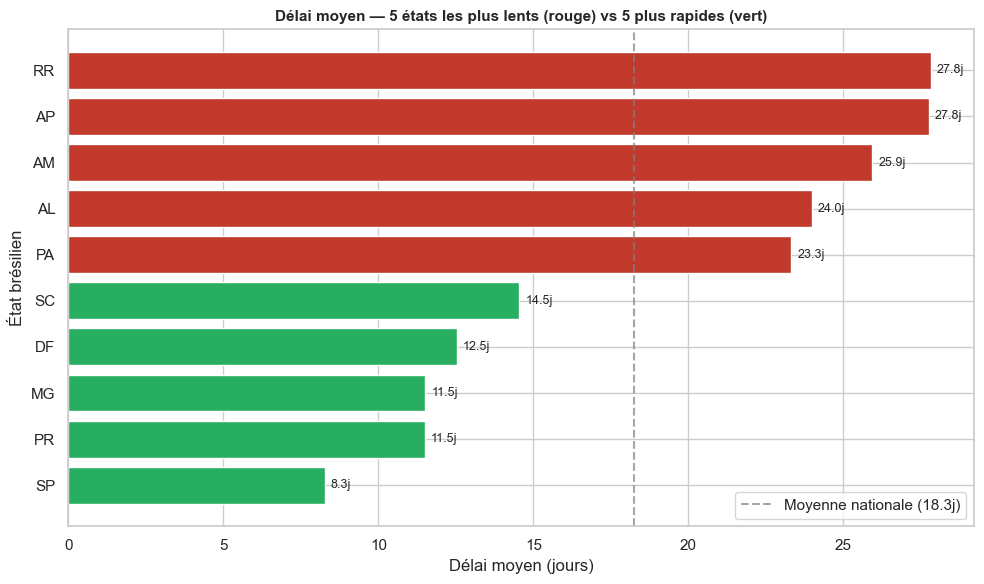

In [23]:
top5 = delai_etat.head(5)
bot5 = delai_etat.tail(5)
extremes = pd.concat([top5, bot5])
colors = ['#c0392b'] * 5 + ['#27ae60'] * 5

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(extremes['customer_state'][::-1], extremes['delai_moyen_j'][::-1],
        color=colors[::-1])
ax.axvline(x=delai_etat['delai_moyen_j'].mean(), linestyle='--', color='grey',
           alpha=0.7, label=f"Moyenne nationale ({delai_etat['delai_moyen_j'].mean():.1f}j)")
ax.set_title('Délai moyen — 5 états les plus lents (rouge) vs 5 plus rapides (vert)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Délai moyen (jours)')
ax.set_ylabel('État brésilien')
for bar, val in zip(ax.patches, extremes['delai_moyen_j'][::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}j', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('../visuals/fig4_delai_etats.png', dpi=150)
plt.show()

**Réponse Q10 :**  
L'état avec le **délai le plus élevé** est **RR (Roraima)** avec 27,8 jours en moyenne, suivi de AP (Amapá, 27,8j) et AM (Amazonas, 25,9j).  
L'état le **plus rapide** est **SP (São Paulo)** avec seulement 8,3 jours, suivi de PR (Paraná, 11,5j) et MG (Minas Gerais, 11,5j).  

**Explication géographique :** Le Brésil est un pays continent de 8,5 millions de km². Les états du **Nord et Nord-Est** (RR, AP, AM, AL, PA) sont géographiquement éloignés des grands centres logistiques, accessibles par des routes limitées ou via des voies fluviales. **São Paulo** concentre l'essentiel des entrepôts et des vendeurs d'Olist, ce qui explique des délais ultra-courts pour les clients locaux. La proximité des entrepôts est le facteur déterminant.

## 3.4 — Satisfaction client et délai de livraison

In [24]:
bins = [0, 7, 14, 21, 999]
labels = ['0-7j', '7-14j', '14-21j', '21j+']
df['delivery_bucket'] = pd.cut(df['delivery_days'], bins=bins, labels=labels)

satisfaction = (
    df.groupby('delivery_bucket', observed=True)['review_score']
    .mean()
    .reset_index()
)
print(satisfaction.to_string())

  delivery_bucket  review_score
0            0-7j      4.330258
1           7-14j      4.198047
2          14-21j      4.022807
3            21j+      2.970995


### Question 11 (1 pt) — Satisfaction par tranche de délai

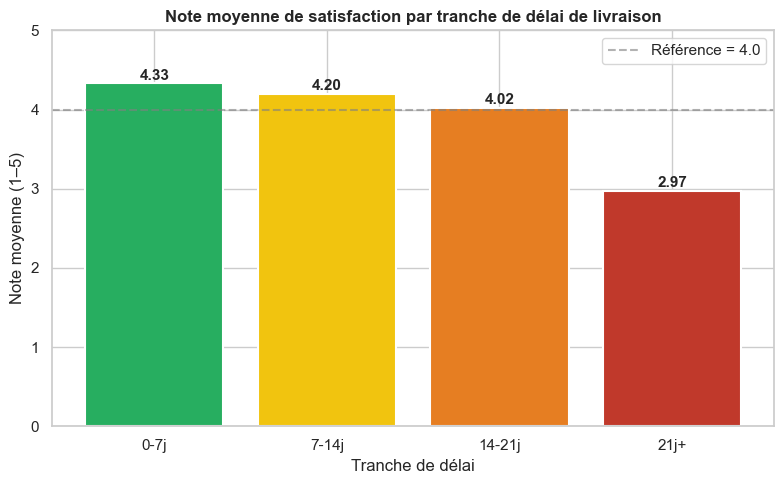

In [25]:
colors_sat = ['#27ae60', '#f1c40f', '#e67e22', '#c0392b']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(satisfaction['delivery_bucket'], satisfaction['review_score'],
              color=colors_sat, edgecolor='white', linewidth=1.5)
ax.set_ylim(0, 5)
ax.set_title('Note moyenne de satisfaction par tranche de délai de livraison',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Tranche de délai')
ax.set_ylabel('Note moyenne (1–5)')
ax.axhline(y=4.0, linestyle='--', color='grey', alpha=0.6, label='Référence = 4.0')
for bar, val in zip(bars, satisfaction['review_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../visuals/fig5_satisfaction_delai.png', dpi=150)
plt.show()

**Interprétation Q11 :**  
Il existe une **corrélation négative claire et forte** entre le délai de livraison et la satisfaction client. Les commandes livrées en moins de 7 jours obtiennent une note moyenne de **4,33/5**, tandis que celles dépassant 21 jours chutent à seulement **2,97/5**.  

La dégradation est progressive mais s'accélère fortement au-delà de 21 jours : les clients acceptent des délais raisonnables (7-14j : 4,20) mais sanctionnent sévèrement les livraisons très tardives. **Réduire les délais de livraison dans les régions lointaines est donc le levier le plus direct pour améliorer la satisfaction globale.** Ce résultat est cohérent avec la corrélation de -0,30 observée dans la matrice de corrélation.

---
# Partie 4 — Visualisations Avancées & Synthèse

## Exercice 1 — Heatmap de corrélation (2 pts)

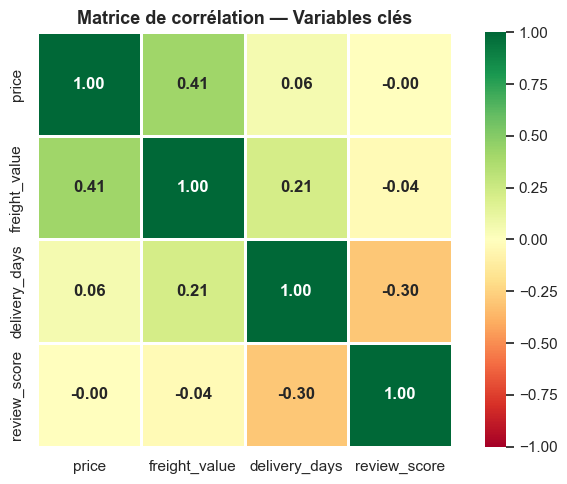

In [26]:
corr_cols = ['price', 'freight_value', 'delivery_days', 'review_score']
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, square=True,
            linewidths=1, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Matrice de corrélation — Variables clés', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/fig6_heatmap_correlation.png', dpi=150)
plt.show()

### Question 12 (1 pt) — Variable la plus corrélée à review_score

**Réponse Q12 :**  
La variable la plus corrélée à la note client (`review_score`) est **`delivery_days`** avec un coefficient de **-0,30**.  

**Le signe négatif** est logique : plus le délai de livraison est long, plus la note est basse. **La force du coefficient (-0,30)** indique une corrélation modérée mais significative sur un dataset de plus de 100 000 lignes — elle est statistiquement robuste. Cela confirme que le délai de livraison est le principal levier d'insatisfaction client chez Olist, davantage que le prix ou le coût de port (corrélations quasi nulles : -0,004 et -0,04 respectivement). Ce résultat n'est pas surprenant dans l'e-commerce : l'expérience de livraison est souvent ce que les clients retiennent le plus.

## Exercice 2 — Distribution des prix (2 pts)

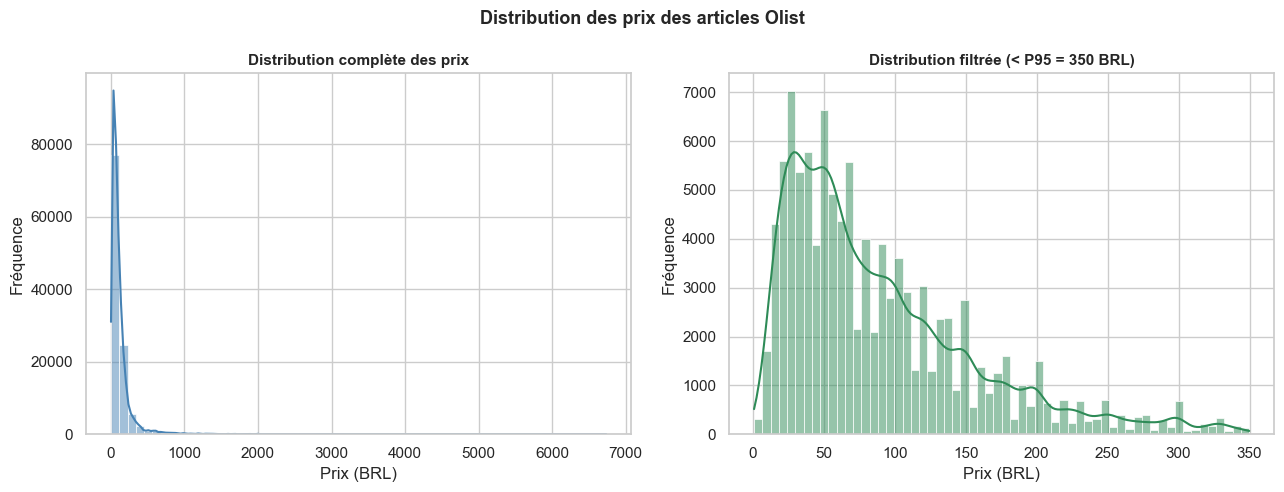

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution complète
sns.histplot(df['price'], kde=True, ax=axes[0], color='steelblue', bins=60)
axes[0].set_title('Distribution complète des prix', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Prix (BRL)')
axes[0].set_ylabel('Fréquence')

# Distribution filtrée (P95)
p95 = df['price'].quantile(0.95)
sns.histplot(df[df['price'] < p95]['price'], kde=True,
             ax=axes[1], color='seagreen', bins=60)
axes[1].set_title(f'Distribution filtrée (< P95 = {p95:.0f} BRL)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Prix (BRL)')
axes[1].set_ylabel('Fréquence')

plt.suptitle('Distribution des prix des articles Olist', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/fig7_distribution_prix.png', dpi=150)
plt.show()

### Question 13 (1 pt) — Forme de la distribution

**Réponse Q13 :**  
La distribution des prix est fortement **asymétrique à droite** (*right-skewed*) : la grande majorité des articles sont vendus entre 0 et 200 BRL, avec une longue queue vers les prix élevés (jusqu'à 6 735 BRL). Cette distribution n'est **pas symétrique**.  

**Implications pour l'analyse statistique :**  
- La **moyenne (120,65 BRL)** est fortement tirée vers le haut par les valeurs extrêmes et ne représente pas le prix typique d'un article.
- La **médiane (74,99 BRL)** est bien plus représentative du comportement d'achat majoritaire.
- Pour toute analyse comparative de prix (par catégorie, par état, etc.), il faudra utiliser la **médiane** et être prudent avec les visualisations incluant les outliers. Le filtrage au P95 (350 BRL) révèle une distribution encore asymétrique mais mieux lisible, concentrée entre 10 et 200 BRL.

## Exercice 3 — Analyse libre : Impact du mode de paiement (2 pts)

**Question business choisie :** Quel mode de paiement est le plus utilisé, et quel est son panier moyen ? Y a-t-il un lien entre le mode de paiement et le montant dépensé ?

In [28]:
# Recharger payments proprement
payments_clean = pd.read_csv(BASE + 'olist_order_payments_dataset.csv',
                              usecols=['order_id','payment_type','payment_installments','payment_value'])
pay_agg = (
    payments_clean
    .groupby('payment_type')
    .agg(nb_commandes=('order_id','count'), panier_moyen=('payment_value','mean'))
    .sort_values('nb_commandes', ascending=False)
    .reset_index()
)
# Exclure les cas non définis
pay_agg = pay_agg[pay_agg['payment_type'] != 'not_defined']
print(pay_agg.round(2).to_string())

  payment_type  nb_commandes  panier_moyen
0  credit_card         76795        163.32
1       boleto         19784        145.03
2      voucher          5775         65.70
3   debit_card          1529        142.57


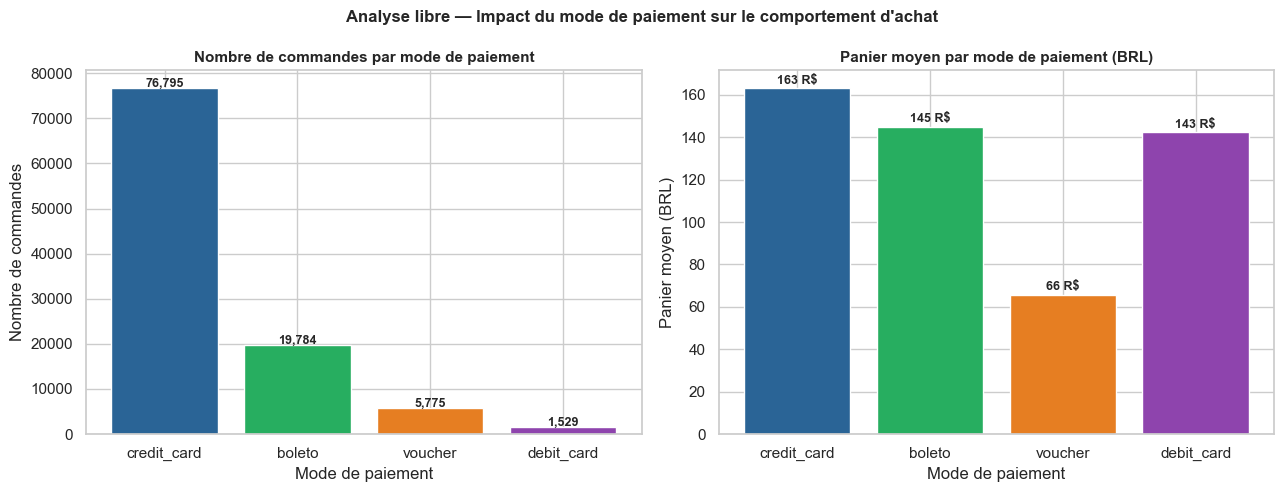

In [29]:
colors_pay = ['#2a6496', '#27ae60', '#e67e22', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graphique 1 : volume par mode de paiement
axes[0].bar(pay_agg['payment_type'], pay_agg['nb_commandes'], color=colors_pay)
axes[0].set_title('Nombre de commandes par mode de paiement', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Mode de paiement')
axes[0].set_ylabel('Nombre de commandes')
for i, val in enumerate(pay_agg['nb_commandes']):
    axes[0].text(i, val + 300, f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# Graphique 2 : panier moyen par mode de paiement
axes[1].bar(pay_agg['payment_type'], pay_agg['panier_moyen'], color=colors_pay)
axes[1].set_title('Panier moyen par mode de paiement (BRL)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Mode de paiement')
axes[1].set_ylabel('Panier moyen (BRL)')
for i, val in enumerate(pay_agg['panier_moyen']):
    axes[1].text(i, val + 2, f'{val:.0f} R$', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Analyse libre — Impact du mode de paiement sur le comportement d\'achat',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/fig8_paiements.png', dpi=150)
plt.show()

**Interprétation de l'analyse libre :**  
La **carte de crédit** est de loin le mode de paiement dominant avec **76 795 transactions** (74% du total), suivie du **boleto** (bon de paiement brésilien, 19 784 transactions). Le **voucher** et la **carte de débit** représentent des usages marginaux.  

Le **panier moyen le plus élevé** appartient à la carte de crédit (**163 R$**), ce qui s'explique par la possibilité d'étaler le paiement en plusieurs mensualités (*parcelamento*) — une pratique très répandue au Brésil qui encourage des achats de montants plus élevés. À l'inverse, les vouchers ont le panier le plus bas (66 R$), car ils sont souvent utilisés pour de petits montants ou des remboursements partiels.

### Question 14 (2 pts) — Conclusion et recommandations

**Trois principaux enseignements de l'analyse :**

**1. La croissance d'Olist est forte mais géographiquement inégale.** Le CA a été multiplié par plus de 8 entre janvier 2017 et fin 2018, avec un pic remarquable lors du Black Friday 2017 (+36% mensuel). Cependant, les délais de livraison varient du simple au triple selon l'état brésilien : 8,3 jours à São Paulo contre 27,8 jours en Roraima, révélant un réseau logistique très concentré dans le Sud-Est du pays.

**2. Le délai de livraison est le principal levier de satisfaction client.** La corrélation de -0,30 entre `delivery_days` et `review_score`, combinée au barplot de satisfaction (4,33/5 pour les livraisons en moins de 7 jours vs 2,97/5 au-delà de 21 jours), démontre sans ambiguïté que réduire les délais améliore directement les notes clients. Le prix et les frais de port ont un impact quasi nul sur la satisfaction.

**3. Health_beauty et watches_gifts sont les catégories motrices du CA.** Elles génèrent respectivement 1,26M et 1,21M de BRL sur la période. La carte de crédit avec paiement fractionné facilite l'achat de produits à plus forte valeur unitaire (163 R$ de panier moyen vs 66 R$ pour les vouchers), ce qui explique en partie la performance des montres et bijoux.

**Deux recommandations concrètes pour l'équipe produit Olist :**

**Recommandation 1 — Créer des hubs logistiques régionaux dans le Nord et Nord-Est.** Les états RR, AP, AM, AL et PA affichent des délais moyens de 24 à 28 jours, bien au-dessus de la moyenne nationale. Olist devrait inciter des vendeurs partenaires à stocker des produits dans ces régions (programme *Fulfillment* régional) pour réduire les délais à moins de 15 jours et améliorer la note moyenne de ces marchés de 2,97 à 4+ sur 5.

**Recommandation 2 — Développer des offres de paiement fractionné sur les catégories à fort potentiel.** Puisque la carte de crédit génère le panier moyen le plus élevé (+12% vs boleto) grâce au *parcelamento*, Olist devrait mettre en avant les options de paiement en 6 ou 12 fois sur les catégories watches_gifts, cool_stuff et electronics — des catégories à prix élevé mais dont le volume de ventes pourrait progresser si le frein financier est levé.

---
# Partie 5 — Exportation et Rendu Final

In [30]:
df.to_csv('../data/processed/olist_df_processed.csv', index=False)
print(f'Export OK — {df.shape[0]} lignes, {df.shape[1]} colonnes')
print(f'Colonnes exportées : {df.columns.tolist()}')

Export OK — 113314 lignes, 21 colonnes
Colonnes exportées : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'delay_days', 'product_id', 'seller_id', 'price', 'freight_value', 'product_category_name_english', 'product_weight_g', 'seller_state', 'customer_state', 'customer_city', 'review_score', 'month', 'delivery_bucket']


## Vérification finale — Checklist

In [31]:
import os

checks = {
    'delivery_days présent dans df': 'delivery_days' in df.columns,
    'delay_days présent dans df': 'delay_days' in df.columns,
    'Types datetime corrects': str(df['order_purchase_timestamp'].dtype) == 'datetime64[ns]',
    'Fichier processed exporté': os.path.exists('../data/processed/olist_df_processed.csv'),
    'Visuals fig2_ca_mensuel': os.path.exists('../visuals/fig2_ca_mensuel.png'),
    'Visuals fig6_heatmap': os.path.exists('../visuals/fig6_heatmap_correlation.png'),
}

for check, status in checks.items():
    icon = '✅' if status else '❌'
    print(f'{icon} {check}')

✅ delivery_days présent dans df
✅ delay_days présent dans df
✅ Types datetime corrects
✅ Fichier processed exporté
✅ Visuals fig2_ca_mensuel
✅ Visuals fig6_heatmap
